# Day 25 – Learning Curves & Regularized Linear Models

- Explain what a **learning curve** is.
- Diagnose **underfitting** and **overfitting** from training and validation errors.
- Understand **bias–variance trade-off**.
- Apply **Ridge**, **Lasso**, and **Elastic Net** regularization.
- Compare model complexity and regularization strength.
- Build intuition for selecting an appropriate model.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11


# 1. Create a synthetic dataset

We generate data from a **quadratic relationship**:

<math display="block"><mi>y</mi><mo>=</mo><mn>0.5</mn><msup><mi>x</mi><mn>2</mn></msup><mo>+</mo><mi>x</mi><mo>+</mo><mn>2</mn><mo>+</mo>noise</math>

A straight line cannot model this perfectly, so it is useful for studying underfitting and overfitting.


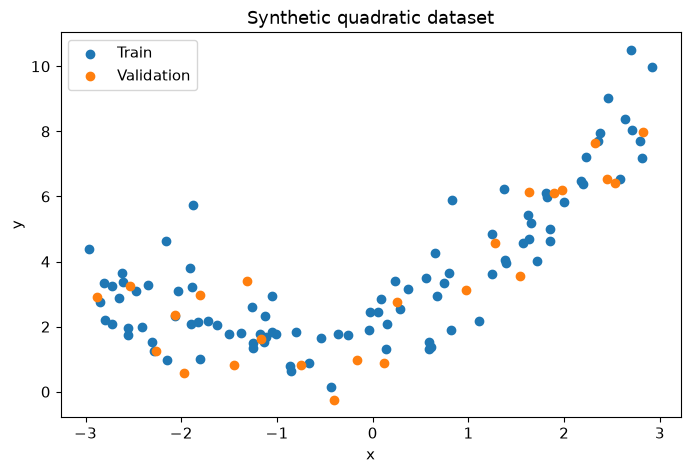

In [23]:
m = 120
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X[:, 0]**2 + X[:, 0] + 2 + np.random.randn(m)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_val, y_val, label="Validation")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic quadratic dataset")
plt.legend()
plt.show()


The scatter plot should show a curved pattern. Keep this shape in mind while evaluating different models.


# 2. What is a learning curve?

A **learning curve** plots model error as the amount of training data increases.

For each training set size we compute:

- **Training RMSE**: error on data used for training.
- **Validation RMSE**: error on unseen validation data.

Typical patterns:

| Pattern | Interpretation |
|---|---|
| Both errors high and close | Underfitting (high bias) |
| Training low, validation much higher | Overfitting (high variance) |
| Both low and close | Good generalization |


In [24]:
def plot_learning_curves(model, X_train, y_train, X_val, y_val, title):
    train_errors, val_errors = [], []

    for m in range(5, len(X_train) + 1):
        model.fit(X_train[:m], y_train[:m])

        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)

        train_errors.append(
            np.sqrt(mean_squared_error(y_train[:m], y_train_predict))
        )
        val_errors.append(
            np.sqrt(mean_squared_error(y_val, y_val_predict))
        )

    plt.plot(train_errors, "r-+", linewidth=2, label="Training RMSE")
    plt.plot(val_errors, "b-", linewidth=2, label="Validation RMSE")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# 3. Underfitting example (high bias)

We train a simple **linear regression** model on curved data.


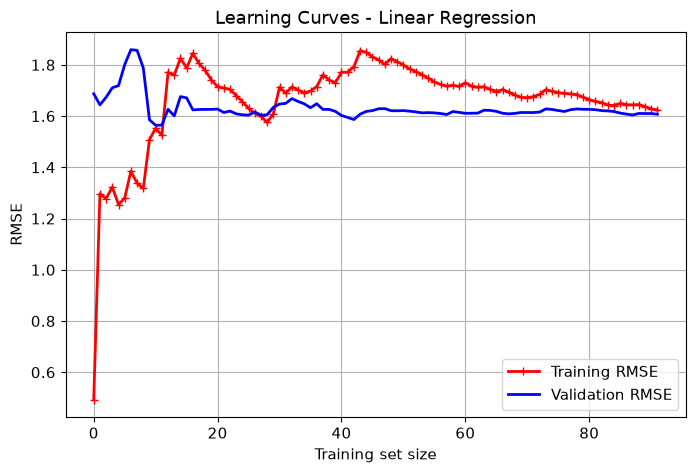

In [25]:
lin_reg = LinearRegression()
plot_learning_curves(
    lin_reg, X_train, y_train, X_val, y_val,
    "Learning Curves - Linear Regression"
)


### Observe

You should notice:

- Training error remains relatively high.
- Validation error is also high.
- The gap between them is small.

This is a classic **underfitting** signature.

### Intuition

The model is too simple to capture the curved relationship. Even with more data, performance does not improve much.


# 4. Better model using polynomial features

We now add polynomial features of degree 10.


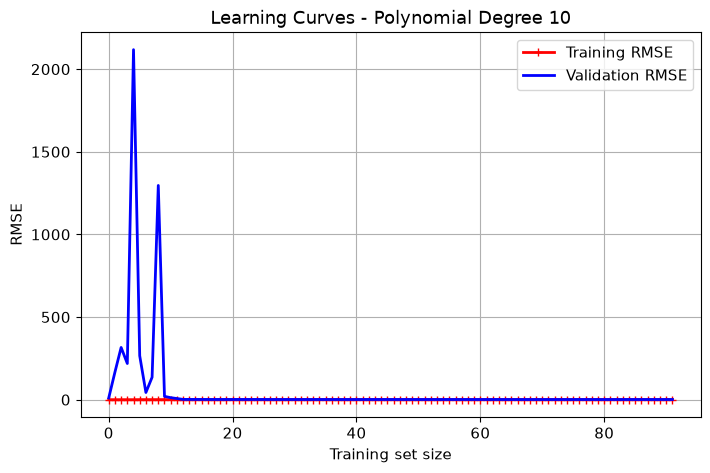

In [26]:
poly10_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("lin_reg", LinearRegression())
])

plot_learning_curves(
    poly10_model, X_train, y_train, X_val, y_val,
    "Learning Curves - Polynomial Degree 10"
)


### Observe

- Training error becomes very low.
- Validation error is higher.
- There is a noticeable gap between the curves.

This indicates **overfitting** (high variance). The model is flexible enough to memorize noise in the training set.


# 5. Visual comparison of models

Let us compare the fitted curves directly.


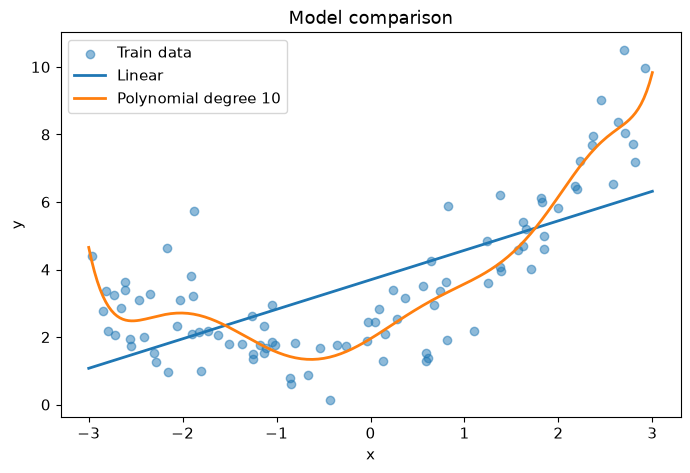

In [27]:
X_new = np.linspace(-3, 3, 200).reshape(-1, 1)

lin_reg.fit(X_train, y_train)
y_lin = lin_reg.predict(X_new)

poly10_model.fit(X_train, y_train)
y_poly10 = poly10_model.predict(X_new)

plt.scatter(X_train, y_train, alpha=0.5, label="Train data")
plt.plot(X_new, y_lin, linewidth=2, label="Linear")
plt.plot(X_new, y_poly10, linewidth=2, label="Polynomial degree 10")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Model comparison")
plt.legend()
plt.show()


### Interpretation

- **Linear model** misses the curvature → underfitting.
- **Degree 10 model** bends aggressively → risk of overfitting.
- A moderate degree often works best.


# 6. Bias–variance trade-off

Think of prediction error as:

<math display="block"><mtext>Total Error</mtext><mo>=</mo><mtext>Bias</mtext><mo>+</mo><mtext>Variance</mtext><mo>+</mo><mtext>Irreducible Noise</mtext></math>

<Table columnSizing="equal" rowDivider={1}><Table.Row header><Table.Cell>Situation</Table.Cell><Table.Cell align="end">Bias</Table.Cell><Table.Cell align="end">Variance</Table.Cell></Table.Row><Table.Row><Table.Cell>Very simple model</Table.Cell><Table.Cell align="end">High</Table.Cell><Table.Cell align="end">Low</Table.Cell></Table.Row><Table.Row><Table.Cell>Very complex model</Table.Cell><Table.Cell align="end">Low</Table.Cell><Table.Cell align="end">High</Table.Cell></Table.Row><Table.Row><Table.Cell>Balanced model</Table.Cell><Table.Cell align="end">Moderate</Table.Cell><Table.Cell align="end">Moderate</Table.Cell></Table.Row></Table>

### Simple analogy

- **High bias**: using a ruler to draw a curved road.
- **High variance**: drawing a different road every time you see a few points.
- **Good balance**: capturing the overall curve without chasing every noisy point.


# 7. Diagnose underfitting vs overfitting numerically

We compare RMSE values.


In [28]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(X_train)
    ))
    val_rmse = np.sqrt(mean_squared_error(
        y_val, model.predict(X_val)
    ))

    print(f"{name}")
    print(f"Train RMSE      : {train_rmse:.3f}")
    print(f"Validation RMSE : {val_rmse:.3f}")
    print(f"Gap             : {val_rmse - train_rmse:.3f}")
    print("-" * 40)

evaluate_model("Linear Regression", lin_reg)
evaluate_model("Polynomial Degree 10", poly10_model)


Linear Regression
Train RMSE      : 1.624
Validation RMSE : 1.607
Gap             : -0.016
----------------------------------------
Polynomial Degree 10
Train RMSE      : 0.928
Validation RMSE : 1.007
Gap             : 0.079
----------------------------------------


### Read the results

- Large errors and small gap → **underfitting**.
- Small training error but much larger validation error → **overfitting**.


# 8. Why regularization?

Regularization discourages excessively large coefficients.

General idea:

<math display="block"><mtext>Loss</mtext><mo>=</mo><mtext>Data Error</mtext><mo>+</mo><mi>α</mi><mo>×</mo><mtext>Penalty</mtext></math>

Increasing **α (alpha)** increases the penalty and usually reduces overfitting.


# 9. Ridge Regression (L2)

Ridge adds a squared-weight penalty.

<math display="block"><mtext>Penalty</mtext><mo>=</mo><munder><mo>∑</mo><mi>j</mi></munder><msubsup><mi>w</mi><mi>j</mi><mn>2</mn></msubsup></math>

Effect:

- Shrinks coefficients smoothly.
- Rarely makes coefficients exactly zero.
- Good default regularization method.


In [29]:
ridge_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

evaluate_model("Ridge Regression (alpha=1)", ridge_model)


Ridge Regression (alpha=1)
Train RMSE      : 0.957
Validation RMSE : 1.019
Gap             : 0.062
----------------------------------------


Notice how validation performance often improves compared with the unregularized degree-10 model.


# 10. Effect of alpha in Ridge

Let us try multiple alpha values.


In [30]:
alphas = [0, 0.01, 0.1, 1, 10, 100]
results = []

for alpha in alphas:
    model = Pipeline([
        ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(X_train)
    ))
    val_rmse = np.sqrt(mean_squared_error(
        y_val, model.predict(X_val)
    ))

    results.append([alpha, train_rmse, val_rmse])

results_df = pd.DataFrame(
    results, columns=["alpha", "train_rmse", "val_rmse"]
)

results_df


,alpha,train_rmse,val_rmse
0,0.00,0.927901,1.006623
1,0.01,0.932488,1.024994
2,0.10,0.940153,1.006841
3,1.00,0.957469,1.018978
4,10.00,1.001651,1.105305
5,100.00,1.254045,1.426901


### Interpretation

- **alpha = 0** → no regularization.
- Small alpha → gentle shrinkage.
- Very large alpha → model becomes too constrained and may underfit.


# 11. Visualize Ridge regularization

This plot shows how the fitted curve changes as alpha increases.


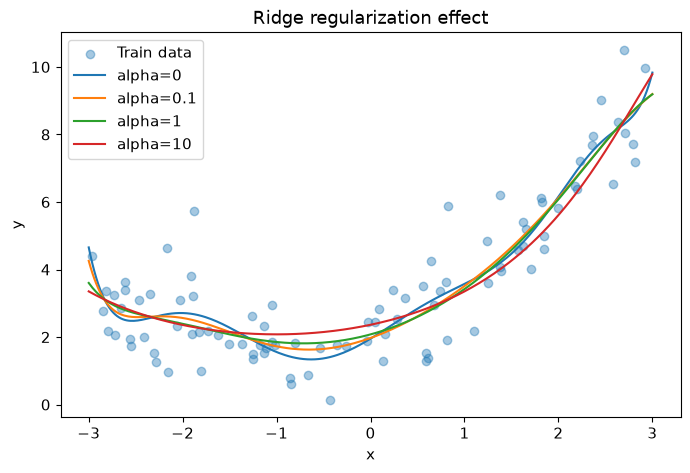

In [31]:
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.scatter(X_train, y_train, alpha=0.4, label="Train data")

for alpha in [0, 0.1, 1, 10]:
    model = Pipeline([
        ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, label=f"alpha={alpha}")

plt.title("Ridge regularization effect")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


Observe that larger alpha values produce smoother curves.


# 12. Lasso Regression (L1)

Lasso uses the absolute values of coefficients.

<math display="block"><mtext>Penalty</mtext><mo>=</mo><munder><mo>∑</mo><mi>j</mi></munder><mfenced open="|" close="|"><msub><mi>w</mi><mi>j</mi></msub></mfenced></math>

Unique property:

- Can force some coefficients to **exactly zero**.
- Performs **feature selection** automatically.


In [32]:
lasso_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.01, max_iter=10000))
])

evaluate_model("Lasso Regression", lasso_model)


Lasso Regression
Train RMSE      : 0.965
Validation RMSE : 1.011
Gap             : 0.047
----------------------------------------


# 13. Inspect Lasso coefficients

Many coefficients may become zero.


In [33]:
lasso_model.fit(X_train, y_train)

coef = lasso_model.named_steps["lasso"].coef_

coef_df = pd.DataFrame({
    "feature_degree": np.arange(1, len(coef) + 1),
    "coefficient": coef
})

coef_df


,feature_degree,coefficient
0,1,1.486633
1,2,1.441765
2,3,0.180661
3,4,-0.000000
4,5,0.046161
5,6,-0.152712
6,7,0.000000
7,8,-0.000000
8,9,-0.000000
9,10,0.000000


Look for coefficients that are exactly **0.0**. Those polynomial terms were effectively removed by Lasso.


# 14. Elastic Net

Elastic Net combines Ridge and Lasso.

<math display="block"><mtext>Penalty</mtext><mo>=</mo><mi>r</mi><mo>×</mo><mtext>L1</mtext><mo>+</mo><mo stretchy="false">(</mo><mn>1</mn><mo>−</mo><mi>r</mi><mo stretchy="false">)</mo><mo>×</mo><mtext>L2</mtext></math>

Useful when:

- Features are correlated.
- You want some feature selection but also coefficient stability.


In [34]:
elastic_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
])

evaluate_model("Elastic Net", elastic_model)


Elastic Net
Train RMSE      : 0.961
Validation RMSE : 1.016
Gap             : 0.056
----------------------------------------


# 15. Compare all models

This table summarizes performance.


In [35]:
models = {
    "Linear": lin_reg,
    "Poly10": poly10_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elastic_model
}

summary = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(X_train)
    ))
    val_rmse = np.sqrt(mean_squared_error(
        y_val, model.predict(X_val)
    ))

    summary.append([name, train_rmse, val_rmse])

summary_df = pd.DataFrame(
    summary, columns=["Model", "Train RMSE", "Validation RMSE"]
)

summary_df.sort_values("Validation RMSE")


,Model,Train RMSE,Validation RMSE
1,Poly10,0.927901,1.006623
3,Lasso,0.964548,1.011094
4,ElasticNet,0.960630,1.016380
2,Ridge,0.957469,1.018978
0,Linear,1.623501,1.607066


The best validation RMSE is usually the best generalizing model among these candidates.
